# AO1 Clase 2 – Limpieza, Transformación y Análisis Exploratorio de Datos con LLMs
## Yohana Vega


## 1. Carga de datos
Se construye el dataset de empleados a partir de los datos dados en la consigna.

In [1]:
# Librerías para manipulación, análisis y gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Herramientas de preprocesamiento
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

In [2]:
# Construcción del DataFrame con los datos del ejercicio
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "Maria", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoría": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,Maria,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


## 1. Observación inicial del conjunto de datos

En esta etapa se revisa la estructura general del dataset para identificar posibles problemas de calidad, como valores faltantes, datos inconsistentes o registros que necesiten corrección antes del análisis.

In [3]:
print("Información general del dataset:")
print(df.info())

print("\nResumen descriptivo:")
print(df.describe(include="all"))

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoría        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 412.0+ bytes
None

Resumen descriptivo:
              ID Nombre      Edad Nivel_Educativo        Salario Categoría  \
count   5.000000      5   5.00000               5       4.000000         5   
unique       NaN      5       NaN               3            NaN         3   
top          NaN   Juan       NaN      Licenciado            NaN    Junior   
freq         NaN      1       NaN              

## 2. Clasificación de las variables

- *ID:* dato numérico entero. Funciona como identificador y no aporta valor analítico directo.
- *Nombre:* dato categórico nominal. Se utiliza solo como referencia.
- *Edad:* dato numérico. Debe controlarse porque puede contener errores de carga.
- *Nivel_Educativo:* variable categórica ordinal, ya que existe una jerarquía entre niveles.
- *Salario:* variable numérica continua. Puede presentar faltantes y valores extremos.
- *Categoria:* variable categórica ordinal, porque representa niveles jerárquicos dentro del trabajo.
- *Estado:* variable categórica nominal/binaria. Requiere unificación por inconsistencias de escritura.

In [4]:
print("Cantidad de valores faltantes por columna:")
print(df.isnull().sum())

print("\nRegistros con edad inválida:")
print(df[df["Edad"] < 0])

print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

print("\nValores encontrados en la columna Estado:")
print(df["Estado"].unique())

Cantidad de valores faltantes por columna:
ID                 0
Nombre             0
Edad               0
Nivel_Educativo    0
Salario            1
Categoría          0
Estado             0
dtype: int64

Registros con edad inválida:
   ID Nombre  Edad Nivel_Educativo  Salario Categoría  Estado
1   2  Maria   -28       Ingeniero  60000.0    Senior  ACTIVO

Cantidad de filas duplicadas:
0

Valores encontrados en la columna Estado:
['Activo' 'ACTIVO' 'Inactivo']


## 3. Limpieza de datos

A partir del diagnóstico inicial, se detectaron tres problemas principales:

1. Una edad con valor negativo.
2. Un salario faltante.
3. Inconsistencias en la variable categórica *Estado*.

Para resolverlos:
- la edad negativa se corrige usando valor absoluto,
- el salario faltante se reemplaza por la mediana,
- y los valores de la columna Estado se normalizan para que tengan un mismo formato.

In [5]:
# Corrección de edades negativas
df["Edad"] = df["Edad"].abs()
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,Maria,28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [6]:
# Reemplazo del valor faltante en salario por la mediana
df["Salario"] = df["Salario"].fillna(df["Salario"].median())
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,Maria,28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [7]:
# Estandarización de los valores categóricos en Estado
df["Estado"] = df["Estado"].str.capitalize()
print(df["Estado"].unique())

['Activo' 'Inactivo']


## 4. Detección de valores atípicos en Salario

Para identificar posibles outliers en la variable *Salario*, se utiliza el método del rango intercuartílico (IQR).  
Este procedimiento permite detectar valores demasiado alejados del resto de la distribución.

In [8]:
Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Primer cuartil (Q1):", Q1)
print("Tercer cuartil (Q3):", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

print("\nPosibles outliers:")
print(df[(df["Salario"] < limite_inferior) | (df["Salario"] > limite_superior)])

Primer cuartil (Q1): 55000.0
Tercer cuartil (Q3): 60000.0
IQR: 5000.0
Límite inferior: 47500.0
Límite superior: 67500.0

Posibles outliers:
   ID Nombre  Edad Nivel_Educativo   Salario Categoría    Estado
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


In [9]:
# Eliminación de valores atípicos en la columna Salario
df = df[(df["Salario"] >= limite_inferior) & (df["Salario"] <= limite_superior)]
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo


## 5. Transformación de variables

Una vez realizado el proceso de limpieza, se transforman algunas variables para facilitar su análisis:

- *Nivel_Educativo* se convierte a formato numérico mediante codificación ordinal.
- *Categoria* también se codifica de forma ordinal.
- *Estado* se transforma en una variable binaria.
- *Salario* se normaliza para llevarlo a una escala comparable.
- Se crea una nueva variable llamada *Anios_Hasta_Jubilacion*.

In [10]:
encoder_nivel = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df.loc[:, "Nivel_Cod"] = encoder_nivel.fit_transform(df[["Nivel_Educativo"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0


In [11]:
encoder_categoria = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
df.loc[:, "Categoria_Cod"] = encoder_categoria.fit_transform(df[["Categoría"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoria_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0


In [12]:
df["Estado_Cod"] = df["Estado"].map({"Activo": 1, "Inactivo": 0})

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1


In [13]:
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50


In [14]:
df["Anios_Hasta_Jubilacion"] = 65 - df["Edad"]

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00,33
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50,30


## 6. Dataset luego de la limpieza y transformación

En esta tabla se observa el resultado final del preprocesamiento aplicado al conjunto de datos.

In [15]:
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00,33
1,2,Maria,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50,30


In [16]:
print("Estadísticas descriptivas del dataset procesado:")
print(df.describe())

Estadísticas descriptivas del dataset procesado:
             ID       Edad       Salario  Nivel_Cod  Categoria_Cod  \
count  4.000000   4.000000      4.000000   4.000000        4.00000   
mean   2.500000  33.750000  55625.000000   0.750000        0.50000   
std    1.290994   5.057997   4269.562819   0.957427        0.57735   
min    1.000000  28.000000  50000.000000   0.000000        0.00000   
25%    1.750000  31.000000  53750.000000   0.000000        0.00000   
50%    2.500000  33.500000  56250.000000   0.500000        0.50000   
75%    3.250000  36.250000  58125.000000   1.250000        1.00000   
max    4.000000  40.000000  60000.000000   2.000000        1.00000   

       Estado_Cod  Salario_Normalizado  Anios_Hasta_Jubilacion  
count        4.00             4.000000                4.000000  
mean         0.75             0.562500               31.250000  
std          0.50             0.426956                5.057997  
min          0.00             0.000000               25.0000

In [17]:
print("Matriz de correlación:")
print(df[["Edad", "Salario", "Nivel_Cod", "Categoria_Cod", "Estado_Cod", "Anios_Hasta_Jubilacion"]].corr())

Matriz de correlación:
                            Edad   Salario  Nivel_Cod  Categoria_Cod  \
Edad                    1.000000 -0.067530   0.464620       0.057073   
Salario                -0.067530  1.000000   0.662541       0.845154   
Nivel_Cod               0.464620  0.662541   1.000000       0.904534   
Categoria_Cod           0.057073  0.845154   0.904534       1.000000   
Estado_Cod             -0.823778 -0.292770  -0.870388      -0.577350   
Anios_Hasta_Jubilacion -1.000000  0.067530  -0.464620      -0.057073   

                        Estado_Cod  Anios_Hasta_Jubilacion  
Edad                     -0.823778               -1.000000  
Salario                  -0.292770                0.067530  
Nivel_Cod                -0.870388               -0.464620  
Categoria_Cod            -0.577350               -0.057073  
Estado_Cod                1.000000                0.823778  
Anios_Hasta_Jubilacion    0.823778                1.000000  


## 7. Análisis exploratorio de datos (EDA)

En esta etapa se utilizan visualizaciones para comprender mejor la distribución del salario y observar posibles relaciones entre variables numéricas.

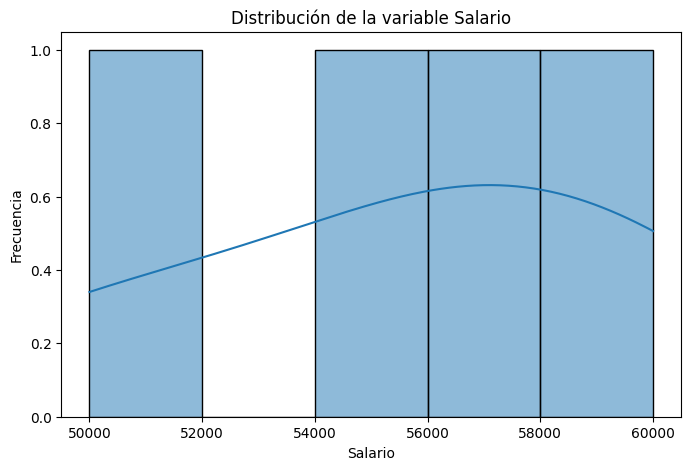

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Salario"], bins=5, kde=True)
plt.title("Distribución de la variable Salario")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

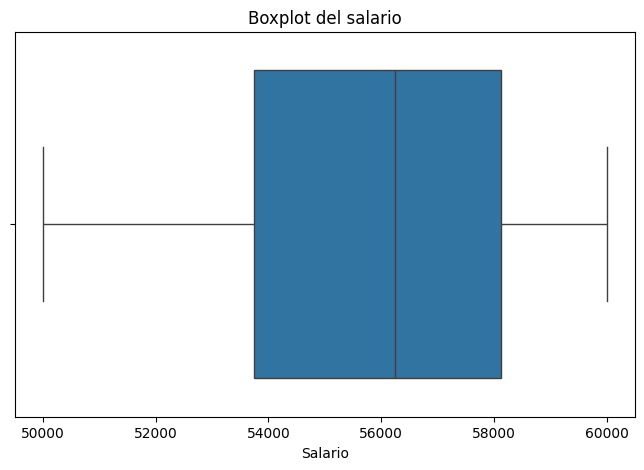

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Salario"])
plt.title("Boxplot del salario")
plt.xlabel("Salario")
plt.show()

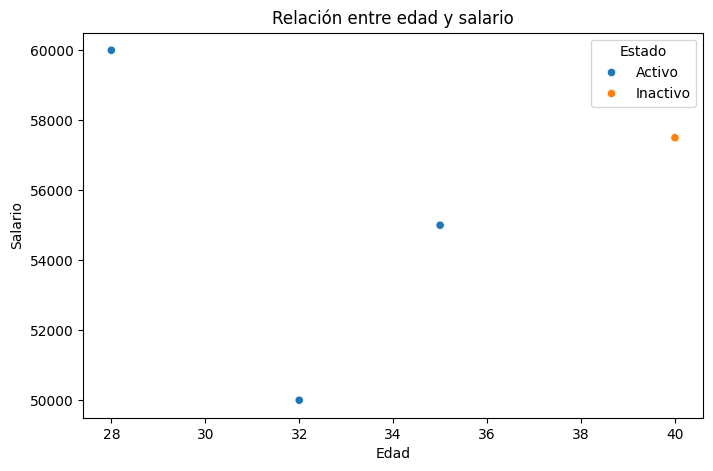

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Edad", y="Salario", hue="Estado")
plt.title("Relación entre edad y salario")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.show()

## 8. Interpretación de resultados

A partir del análisis realizado, se encontraron varios aspectos importantes:

- Se detectó un salario faltante y se reemplazó utilizando la mediana.
- Se corrigió una edad cargada de forma incorrecta.
- Se unificó la escritura de la variable Estado para evitar inconsistencias.
- Se identificó un valor atípico en Salario mediante el método IQR y se decidió eliminarlo.
- Las visualizaciones permiten observar la distribución salarial y analizar cómo se relacionan la edad y el salario dentro del conjunto de datos.

## 9. Uso de LLM

### Prompt 1
"¿Qué método simple puedo usar en Python para detectar valores atípicos en una columna numérica?"

### Síntesis de la respuesta
La respuesta sugirió utilizar el método IQR, ya que permite identificar valores extremos a partir de los cuartiles y del rango intercuartílico. También explicó que este criterio es útil cuando se quiere limpiar un conjunto de datos antes del análisis.

### Validación personal
Se eligió ese método porque resulta claro, fácil de aplicar y además coincide con las estrategias vistas en clase para detectar outliers en variables numéricas.

### Prompt 2
"¿Qué gráficos son útiles para explorar la relación entre edad y salario en un dataset pequeño?"

### Síntesis de la respuesta
El modelo propuso utilizar histogramas para observar la distribución, boxplots para detectar dispersión o valores extremos y gráficos de dispersión para analizar la relación entre dos variables numéricas.

### Validación personal
Estas sugerencias fueron aplicadas en el trabajo, ya que permiten obtener una visión general del dataset y facilitan la interpretación previa a cualquier modelo.


## 10. Conclusión

En esta actividad se aplicaron distintas etapas del preprocesamiento de datos: identificación de variables, limpieza, transformación y análisis exploratorio.

Primero se detectaron errores e inconsistencias en el dataset, luego se corrigieron los valores problemáticos y se transformaron variables categóricas a numéricas. Finalmente, mediante gráficos y estadísticas descriptivas, fue posible interpretar mejor el comportamiento de los datos y su estructura general.